In [1]:
import gc
import json 
from pathlib import Path
import torch
import torch.nn.functional as F
from FLUX_custom_pipeline import FluxPipeline
import argparse
import random

In [2]:
 # Load model
pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-dev", torch_dtype=torch.float16)
pipe.enable_model_cpu_offload()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
pipe.skipped_layers = [5]
prompt = 'A book with \'Fundamentals of Computer Vision\' written on the cover'
seed_generator_normal = torch.Generator("cpu").manual_seed(42)
seed_generator_skipped = torch.Generator("cpu").manual_seed(42)

In [ ]:
image_normal = pipe(
    prompt,
    guidance_scale=3.5, 
    num_inference_steps=28,
    max_sequence_length=256,
    generator=seed_generator_skipped
).images[0]

Performing standard CFG with scale 3.5.


  0%|          | 0/28 [00:00<?, ?it/s]

Performing Skip-Layer Guidance with scale 0.0.


  0%|          | 0/28 [00:00<?, ?it/s]

In [ ]:
for i in range(19):    
    pipe.skipped_layers = [i]
    image_skipped = pipe(
        prompt,
        negative_prompt=prompt,
        guidance_scale=3.5, 
        true_cfg_scale=0.,
        num_inference_steps=28,
        max_sequence_length=256,
        generator=seed_generator_skipped
    ).images[0]

Performing Skip-Layer Guidance with scale 0.0.


  0%|          | 0/28 [00:00<?, ?it/s]

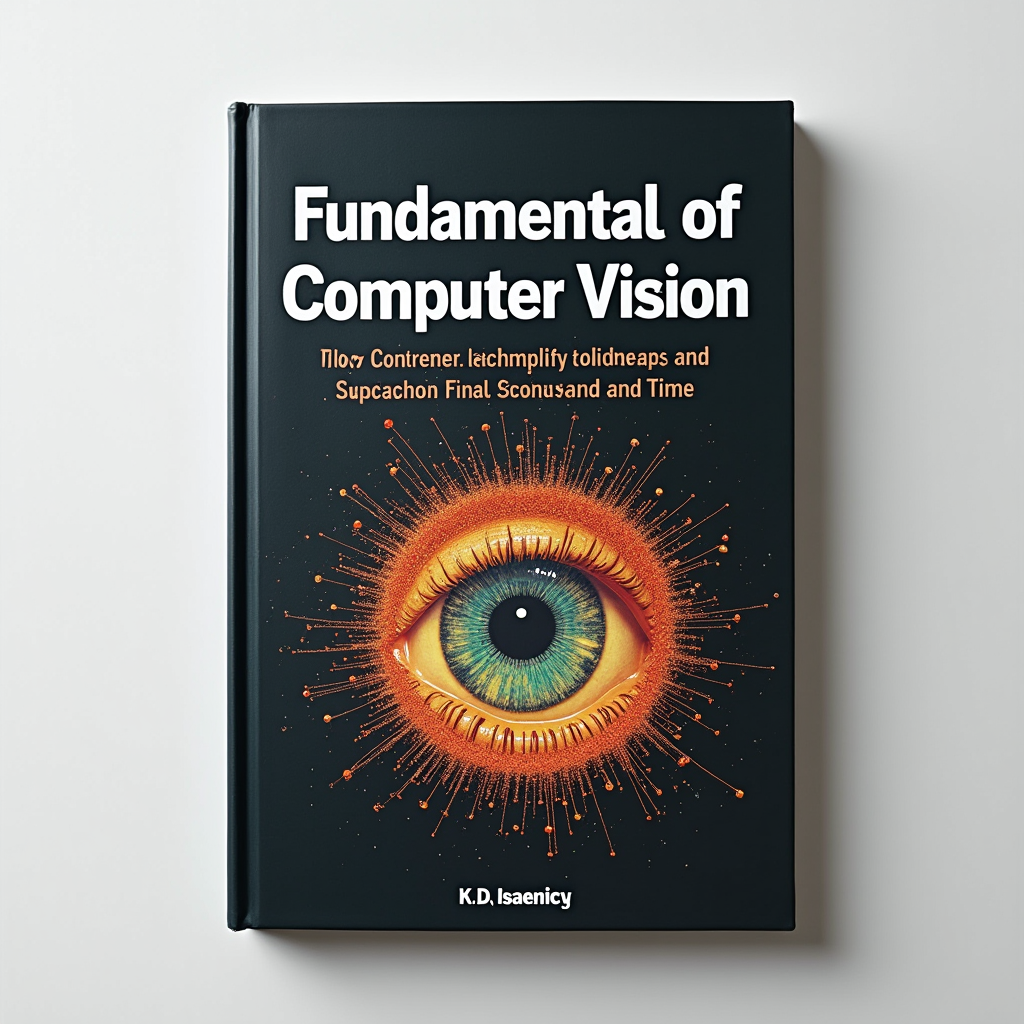

In [6]:
image_normal

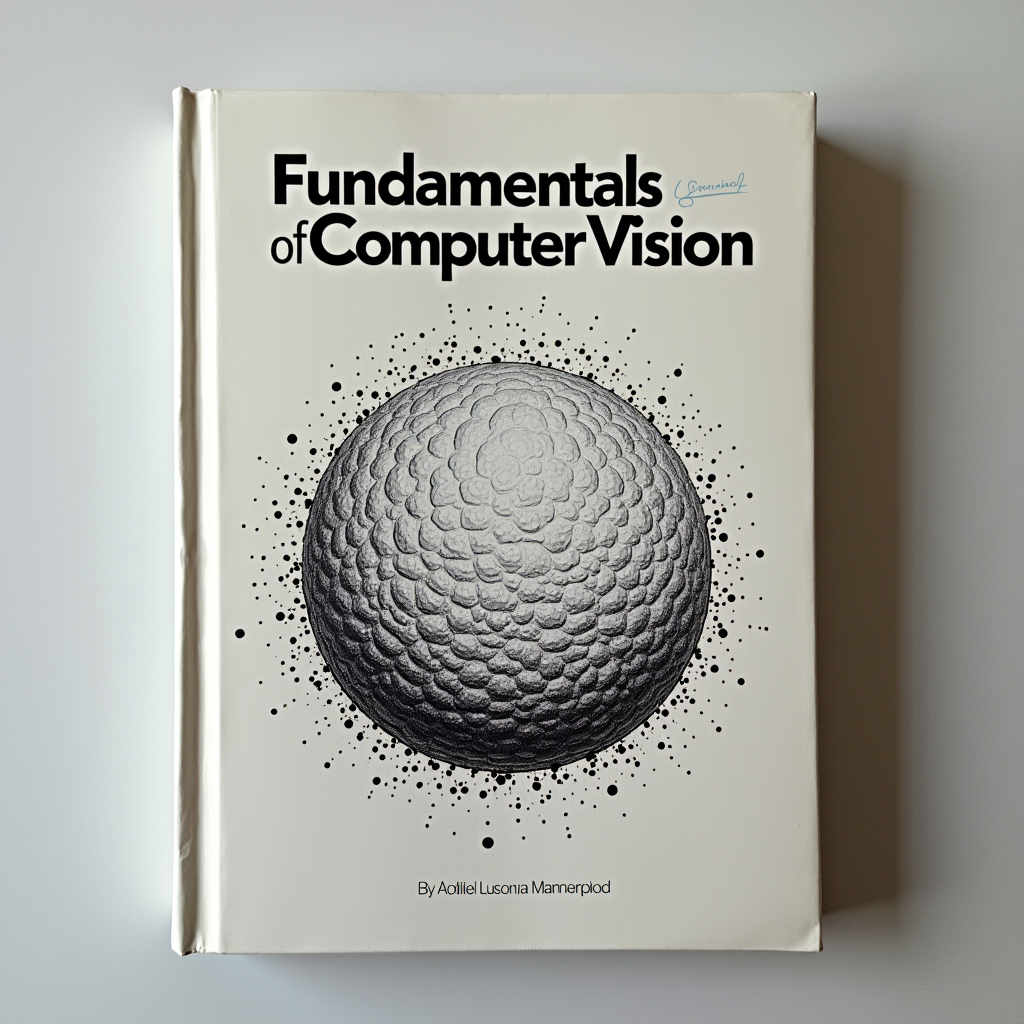

In [9]:
image_skipped